# EDA of the Expanded Groove MIDI Dataset

In [1]:
# The E-GMD dataset is expected under ../data/e-gmd (see repo README / requirements.txt).
# To (re)download it locally, run from the repo root:
#   mkdir -p data && curl -fL -o data/e-gmd-v1.0.0-midi.zip \
#     https://storage.googleapis.com/magentadata/datasets/e-gmd/v1.0.0/e-gmd-v1.0.0-midi.zip
#   unzip -nq data/e-gmd-v1.0.0-midi.zip -d data/e-gmd

In [2]:
import os

In [3]:
DATASET_BASE_PATH = os.path.join('..', '..', 'data', 'e-gmd', 'e-gmd-v1.0.0')
DATASET_METADATA_PATH = os.path.join(DATASET_BASE_PATH, 'e-gmd-v1.0.0.csv')

## Imports

We are going to need [partitura](https://github.com/CPJKU/partitura) for MIDI playback in the notebook. I also recommend this lib for working with MIDI performances and/or scores.

In [4]:
# Dependencies are managed via ../requirements.txt in a venv.
# On a fresh machine / Kaggle, uncomment:
# %pip install -r ../requirements.txt

In [5]:
import sys
sys.path.insert(0, '..')  # make the drum_dynamics package importable from notebooks/

import pandas as pd
import partitura
import matplotlib.pyplot as plt
import numpy as np

# Helpers previously defined inline are now in the drum_dynamics package:
from drum_dynamics import (
    Idx, MidiNote, DRUM_MIDI_NAME, midi_number_to_tone,
    load_note_array, piano_roll, drums_roll,
    play_midi_file, play_midi_notes, set_soundfont,
)

## Helper funcs and classes

1. Partitura gives us an ndarray of tuples, containing note info. Making a helper class to make it easier to work with:

In [6]:
# `Idx` and `MidiNote` are now imported from drum_dynamics.midi (see imports cell above).
# They wrap a partitura note tuple:
#   [0]=onset_secs [1]=duration_secs [2]=onset_ticks [3]=duration_ticks
#   [4]=pitch [5]=velocity [6]=track [7]=channel [8]=id

2. Creating a piano-roll representation of a MIDI track

A piano-roll is a matrix where the rows are the notes and the columns are the time steps.

We can extend it to add the velocity of the note as its value. Color-coding can be used to display the velocity.

That way we would get a nice 3D overview of the performance that shows the velocity of each note at each time step.

In [7]:
# DRUM_MIDI_NAME (General MIDI percussion map) is imported from drum_dynamics.midi.

In [8]:
# drums_roll() / piano_roll() are imported from drum_dynamics.viz.

3. MIDI playback in the notebook


In [9]:
# Playback needs the native FluidSynth library:
#   macOS:  brew install fluid-synth
#   Debian: apt-get install fluidsynth

In [10]:
# pyfluidsynth is installed via ../requirements.txt.

A soundfont needs to be downloaded (that has drums). I will use a General MIDI one: FluidR3_GM.sf2.

In [11]:
# A General MIDI soundfont (with a drum kit) is expected at ../../sf/big/FluidR3_GM.sf2.
# To download it locally, run from the repo root:
#   mkdir -p sf/big && curl -fL -o sf/big/FluidR3_GM.sf2 \
#     'https://raw.githubusercontent.com/urish/cinto/master/media/FluidR3%20GM.sf2'

In [12]:
set_soundfont(os.path.join('..', 'sf', 'big', 'FluidR3_GM.sf2'))

In [13]:
# play_midi_file() / play_midi_notes() are imported from drum_dynamics.playback.
# NOTE: for drum tracks pass is_drums=True so playback routes to the GM percussion set.

## What's inside?

In [14]:
df = pd.read_csv(DATASET_METADATA_PATH)

In [15]:
df.sample(10)

,drummer,session,id,style,bpm,beat_type,time_signature,duration,split,midi_filename,audio_filename,kit_name
9703,drummer1,drummer1/session1,drummer1/session1/213,rock/halftime,140,fill,4-4,1.714286,train,drummer1/session1/213_rock-halftime_140_fill_4...,drummer1/session1/213_rock-halftime_140_fill_4...,Cassette (Lo-Fi Compress)
19307,drummer1,drummer1/session2,drummer1/session2/56,punk,128,fill,4-4,1.803787,train,drummer1/session2/56_punk_128_fill_4-4_1.midi,drummer1/session2/56_punk_128_fill_4-4_1.wav,Acoustic Kit
33509,drummer7,drummer7/session3,drummer7/session3/105,hiphop,70,fill,4-4,3.428571,train,drummer7/session3/105_hiphop_70_fill_4-4_21.midi,drummer7/session3/105_hiphop_70_fill_4-4_21.wav,Pop-Rock (Studio)
41411,drummer1,drummer1/session1,drummer1/session1/261,funk/purdieshuffle,130,fill,4-4,1.846145,validation,drummer1/session1/261_funk-purdieshuffle_130_f...,drummer1/session1/261_funk-purdieshuffle_130_f...,Studio (Live Room)
6343,drummer1,drummer1/session1,drummer1/session1/123,funk,95,fill,4-4,2.526304,train,drummer1/session1/123_funk_95_fill_4-4_33.midi,drummer1/session1/123_funk_95_fill_4-4_33.wav,Shuffle (Blues)
4357,drummer7,drummer7/session3,drummer7/session3/45,rock/indie,63,fill,4-4,3.782494,test,drummer7/session3/45_rock-indie_63_fill_4-4_23...,drummer7/session3/45_rock-indie_63_fill_4-4_23...,Second Line
5326,drummer1,drummer1/session1,drummer1/session1/1,funk,80,beat,4-4,86.964853,train,drummer1/session1/1_funk_80_beat_4-4_55.midi,drummer1/session1/1_funk_80_beat_4-4_55.wav,Ele-Drum
26597,drummer5,drummer5/session2,drummer5/session2/13,rock,140,beat,4-4,56.340045,train,drummer5/session2/13_rock_140_beat_4-4_34.midi,drummer5/session2/13_rock_140_beat_4-4_34.wav,Alternative (METAL)
22083,drummer3,drummer3/session1,drummer3/session1/16,jazz,120,beat,4-4,40.000000,train,drummer3/session1/16_jazz_120_beat_4-4_35.midi,drummer3/session1/16_jazz_120_beat_4-4_35.wav,Rockin Gate (80s)
692,drummer1,drummer1/session1,drummer1/session1/207,rock/halftime,140,fill,4-4,3.428571,test,drummer1/session1/207_rock-halftime_140_fill_4...,drummer1/session1/207_rock-halftime_140_fill_4...,Jazz Funk


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45537 entries, 0 to 45536
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   drummer         45537 non-null  str    
 1   session         45537 non-null  str    
 2   id              45537 non-null  str    
 3   style           45537 non-null  str    
 4   bpm             45537 non-null  int64  
 5   beat_type       45537 non-null  str    
 6   time_signature  45537 non-null  str    
 7   duration        45537 non-null  float64
 8   split           45537 non-null  str    
 9   midi_filename   45537 non-null  str    
 10  audio_filename  45537 non-null  str    
 11  kit_name        45537 non-null  str    
dtypes: float64(1), int64(1), str(10)
memory usage: 4.2 MB


In [17]:
df.describe()

,bpm,duration
count,45537.000000,45537.000000
mean,109.805477,35.140608
std,23.992195,66.746390
min,50.000000,0.669841
25%,95.000000,2.068957
50%,110.000000,3.502789
75%,125.000000,36.179592
max,290.000000,611.754989


array([[<Axes: title={'center': 'bpm'}>,
        <Axes: title={'center': 'duration'}>]], dtype=object)

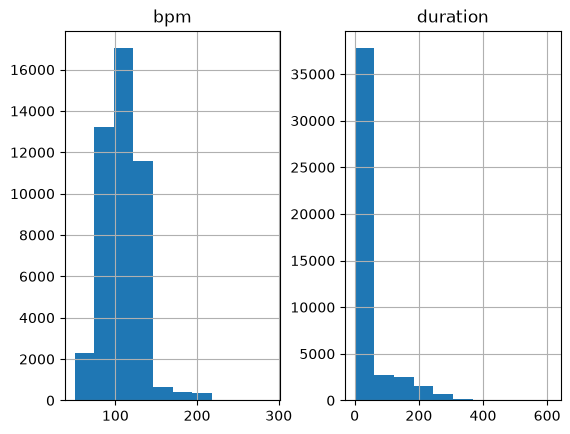

In [18]:
df.hist()

In [19]:
df["style"].value_counts()

style
rock                       10621
hiphop                      3655
funk                        2838
punk                        2494
jazz                        1935
                           ...  
neworleans/chacha             43
neworleans/shuffle            43
latin/bomba                   43
latin/venezuelan-joropo       43
latin/brazilian-frevo         43
Name: count, Length: 74, dtype: int64

In [20]:
df["time_signature"].value_counts()

time_signature
4-4    45021
3-4      215
6-8      215
5-4       43
5-8       43
Name: count, dtype: int64

In [21]:
df["beat_type"].value_counts()

beat_type
fill    26961
beat    18576
Name: count, dtype: int64

In [22]:
df["split"].value_counts()

split
train         35217
test           5289
validation     5031
Name: count, dtype: int64

array([[<Axes: title={'center': 'bpm'}>,
        <Axes: title={'center': 'duration'}>]], dtype=object)

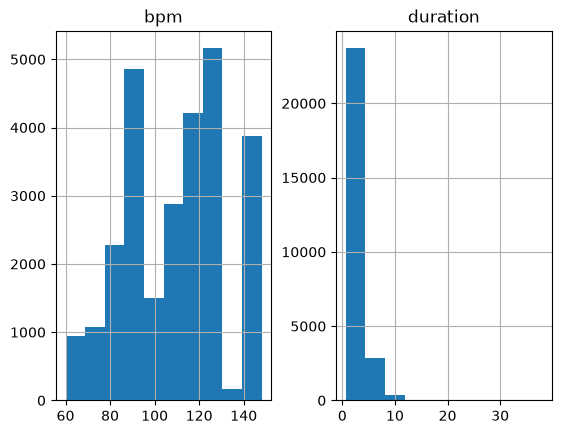

In [23]:
# Only fills
df[df["beat_type"] == "fill"].hist()

array([[<Axes: title={'center': 'bpm'}>,
        <Axes: title={'center': 'duration'}>]], dtype=object)

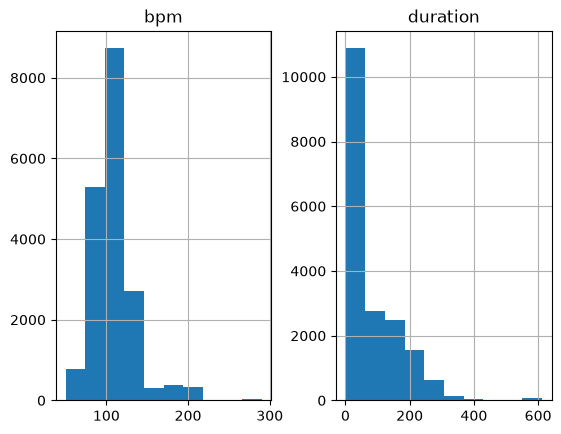

In [24]:
# Only beats
df[df["beat_type"] == "beat"].hist()

### Explore a file

In [25]:
example_midi_filepath = os.path.join(DATASET_BASE_PATH, df.iloc[0]['midi_filename'])
example_midi_filepath

'../data/e-gmd/e-gmd-v1.0.0/drummer1/eval_session/1_funk-groove1_138_beat_4-4_1.midi'

In [26]:
example_midi = partitura.load_performance_midi(example_midi_filepath)
example_midi.performedparts

In [27]:
example_notes = example_midi.performedparts[0].note_array()
example_notes[:10]

array([(0.00271739, 0.10144937,   3, 112, 55, 60, 0, 9, 'n0'),
       (0.00634059, 0.10054357,   7, 111, 51, 55, 0, 9, 'n1'),
       (0.00905798, 0.09963777,  10, 110, 36, 64, 0, 9, 'n2'),
       (0.19112337, 0.10054357, 211, 111, 36, 57, 0, 9, 'n3'),
       (0.2155799 , 0.09963777, 238, 110, 51, 31, 0, 9, 'n4'),
       (0.40398586, 0.10144937, 446, 112, 44, 77, 0, 9, 'n5'),
       (0.42300764, 0.10054357, 467, 111, 51, 54, 0, 9, 'n6'),
       (0.430254  , 0.10054357, 475, 111, 38, 93, 0, 9, 'n7'),
       (0.6032614 , 0.10235517, 666, 113, 44, 52, 0, 9, 'n8'),
       (0.6376817 , 0.10144937, 704, 112, 51, 42, 0, 9, 'n9')],
      dtype=[('onset_sec', '<f4'), ('duration_sec', '<f4'), ('onset_tick', '<i4'), ('duration_tick', '<i4'), ('pitch', '<i4'), ('velocity', '<i4'), ('track', '<i4'), ('channel', '<i4'), ('id', '<U256')])

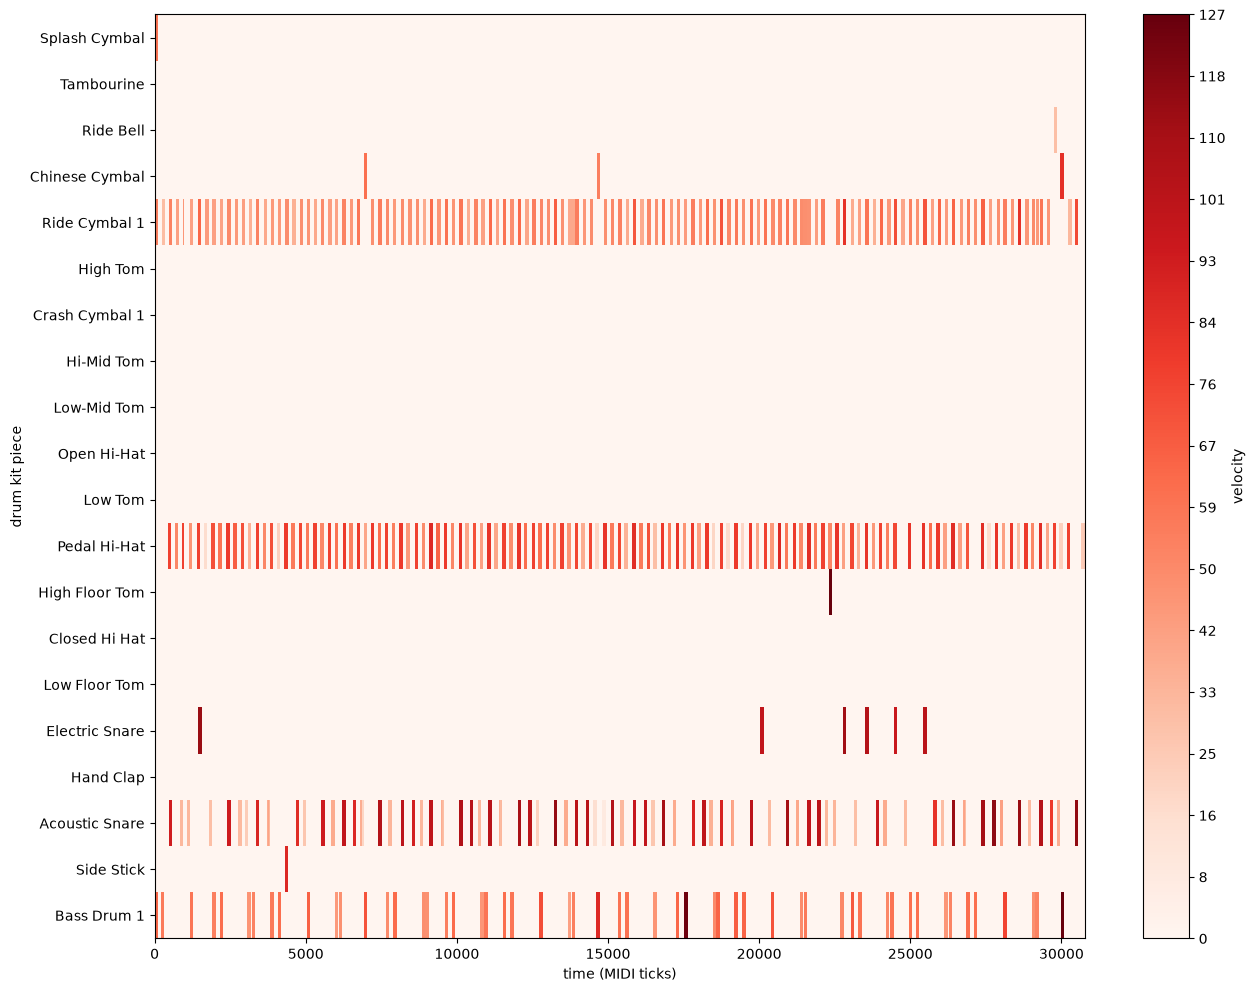

In [28]:
drums_roll(example_notes)

In [29]:
play_midi_notes(example_notes, is_drums=True)